# Figure S9 — Full 14-cluster CDF grid (supplemental to Figure 8E)

Same pipeline as Figure 8E but emits a panel for every B-SOiD cluster
instead of only the two highlighted in 8E (1 and 8). Asterisks mark
(cluster, chamber) cells where at least one pairwise group comparison is
BH-significant under the Wasserstein permutation test — see the table below
for which pairs.

Layout: 7 × 6 grid — left half = even clusters (0/2/4/6/8/10/12), right half
= odd clusters (1/3/5/7/9/11/13), three chambers each.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_context("notebook")

EXPERIMENTAL_GROUPS    = ["NS", "Hx", "LPS", "DH"]
CHAMBER_KEYS           = ["stranger_mouse_chamber", "middle_chamber", "novel_object_chamber"]
CHAMBER_TITLES         = {"stranger_mouse_chamber": "Stranger Mouse Chamber",
                          "middle_chamber":          "Middle Chamber",
                          "novel_object_chamber":    "Novel Object Chamber"}
GROUP_FIGURE_LABEL     = {"NS": "Sal-N", "Hx": "Sal-Hx", "LPS": "LPS-N", "DH": "LPS-Hx"}
GROUP_COLORS           = {"DH":  "#D32F2F", "Hx":  "#1976D2",
                          "LPS": "#FBC02D", "NS":  "#388E3C"}
GROUP_ORDER_LEGEND     = ["DH", "Hx", "LPS", "NS"]


def runs_for(rl_df, cluster, chamber, group):
    sub = rl_df[(rl_df["cluster"] == cluster) &
                (rl_df["chamber"] == chamber) &
                (rl_df["group"]   == group)]
    if sub.empty:
        return np.array([], dtype=int)
    return np.repeat(sub["run_length"].values, sub["count"].values)


def plot_cdfs(ax, rl_df, cluster, chamber, *,
              linewidth=2, fontsize_title=13, fontsize_y=12,
              fontsize_x=11, fontsize_tick=10, fontsize_legend=9,
              show_title=True, show_y=True, show_legend=True):
    max_x = 1
    for g in GROUP_ORDER_LEGEND:
        runs = runs_for(rl_df, cluster, chamber, g)
        if runs.size == 0:
            continue
        sorted_runs = np.sort(runs)
        cdf = np.cumsum(sorted_runs) / sorted_runs.sum()
        ax.step(sorted_runs, cdf, where="post", color=GROUP_COLORS[g],
                linewidth=linewidth, label=GROUP_FIGURE_LABEL[g])
        max_x = max(max_x, int(sorted_runs[-1]))
    ax.set_xscale("log")
    ax.set_xlim(left=1, right=max_x if max_x > 1 else None)
    ax.set_ylim(0, 1.0)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_linewidth(0.8)
    ax.tick_params(axis="both", which="both", labelsize=fontsize_tick)
    if show_title:
        ax.set_title(CHAMBER_TITLES[chamber], fontsize=fontsize_title, pad=10)
    if show_y:
        ax.set_ylabel(f"Group {cluster} CDF", fontsize=fontsize_y)
    ax.set_xlabel("Successive Frames (Log)", fontsize=fontsize_x, labelpad=2)
    if show_legend:
        ax.legend(loc="lower right", fontsize=fontsize_legend, frameon=False)


def sig_lookup_from(wasser_df):
    return (wasser_df.assign(sig=lambda d: d["Adjusted p-value (BH)"] < 0.05)
                     .groupby(["Label", "Chamber"])["sig"].any().to_dict())

def relabel(s):
    s = s.replace("DH",  "LPS-Hx")
    s = s.replace("Hx",  "Sal-Hx")
    s = s.replace("LPS", "LPS-N")
    s = s.replace("NS",  "Sal-N")
    return s

# Use Arial across all figures (publication consistency)
plt.rcParams['font.family'] = 'Arial'


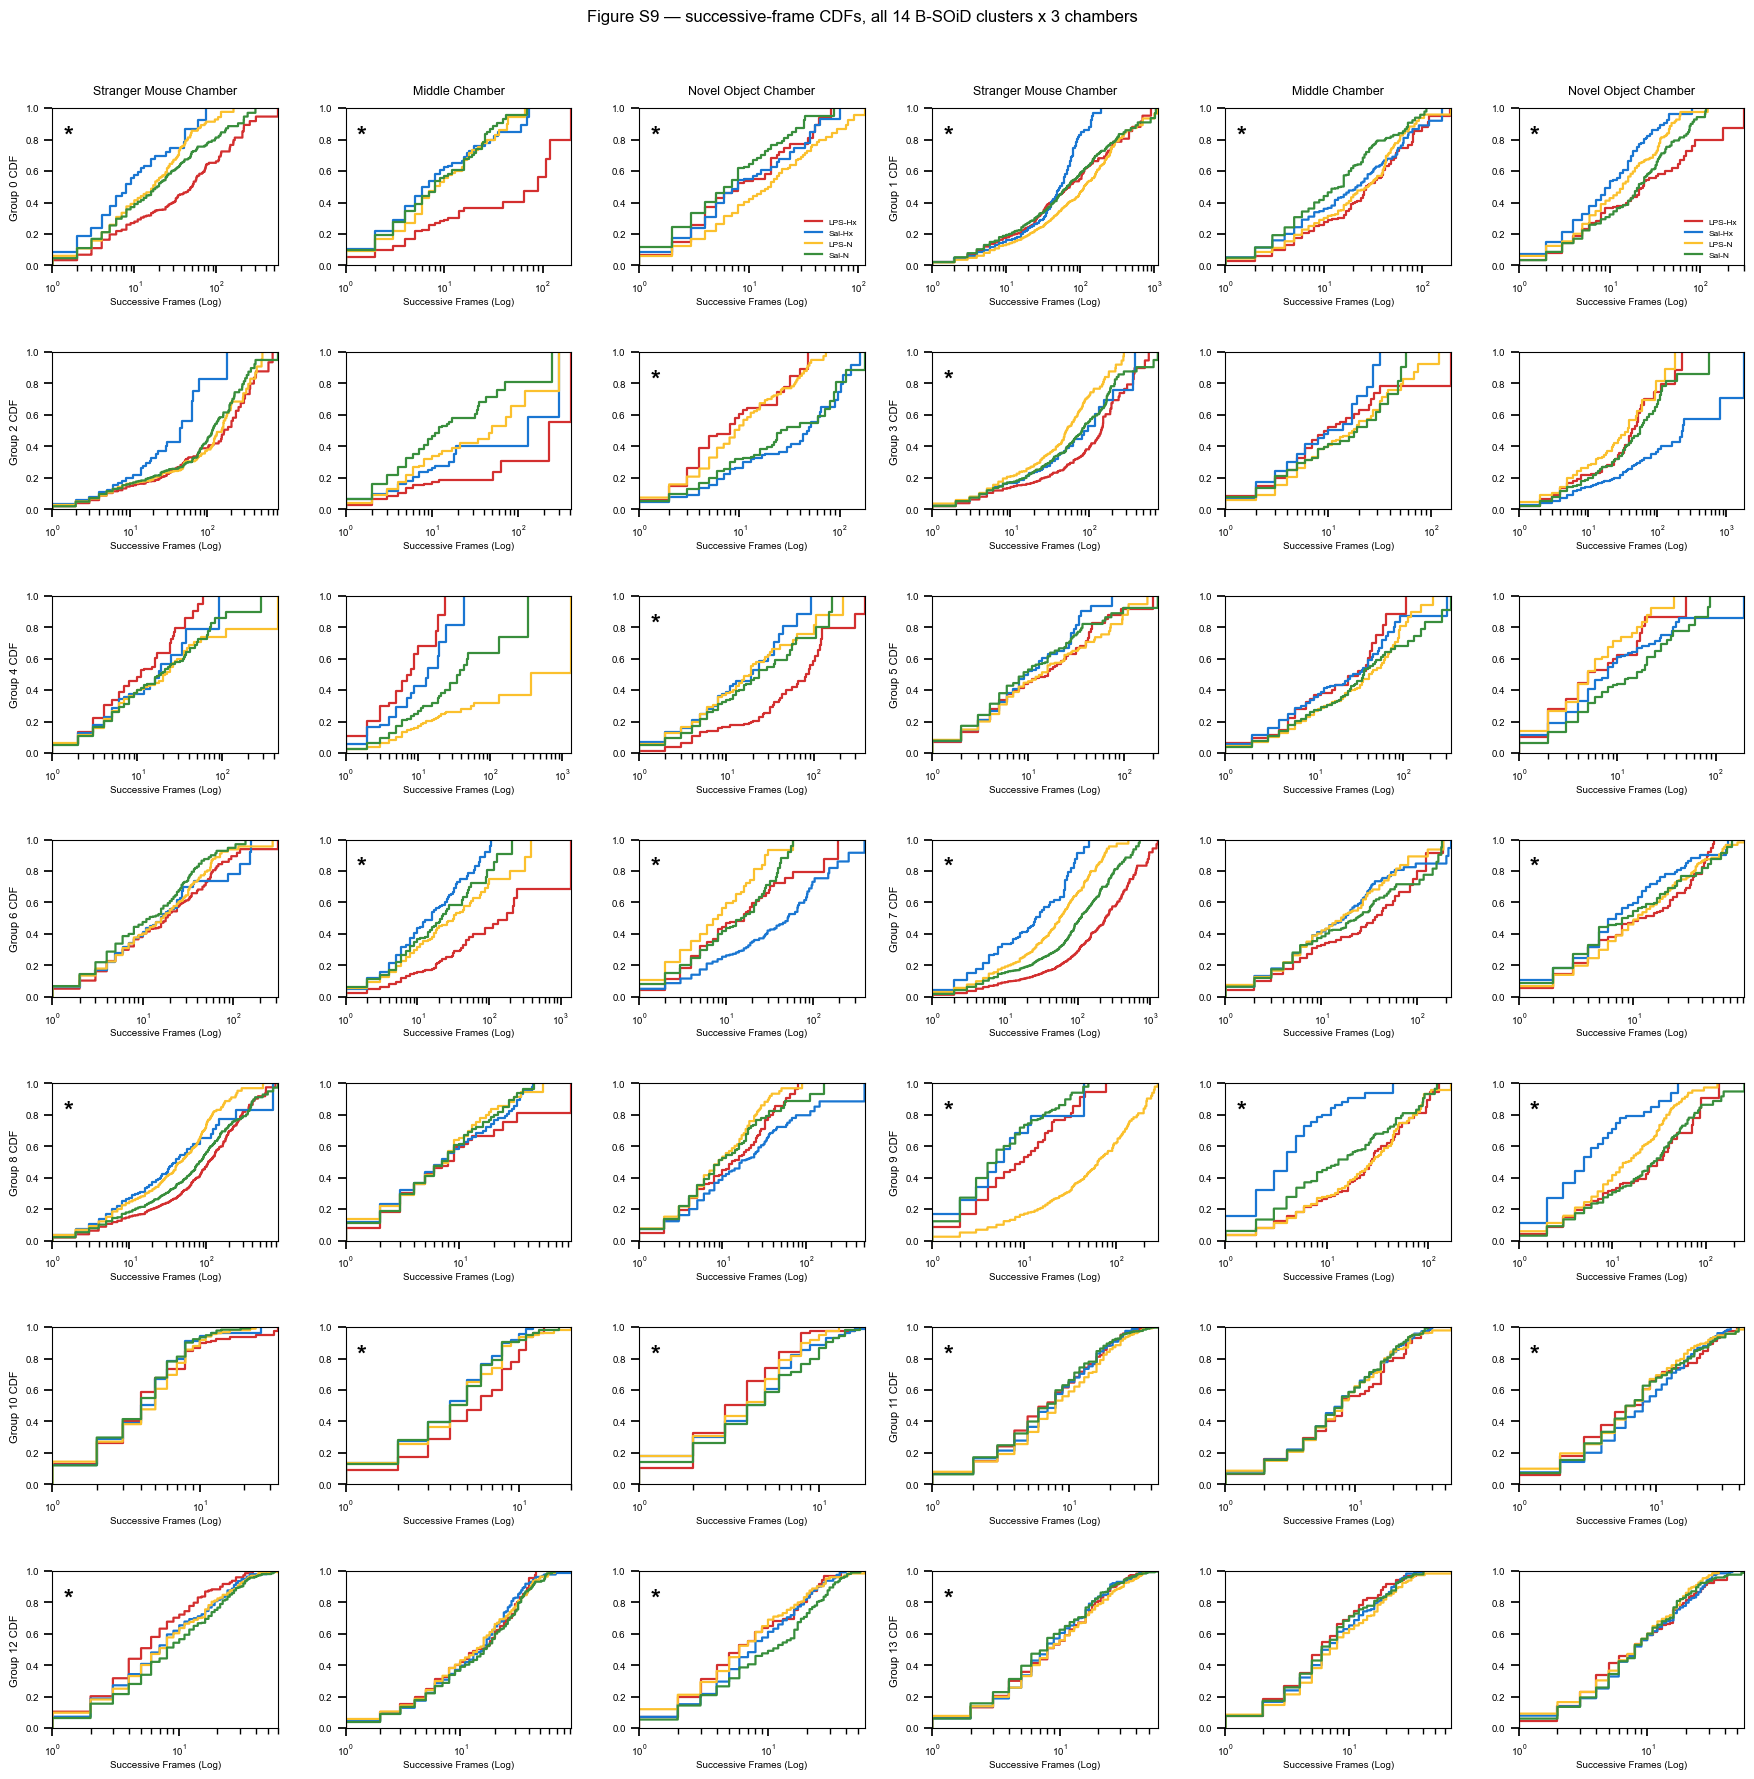

In [2]:
rl = pd.read_csv("data/runlengths.csv")
wasser = pd.read_csv("data/wasserstein_test_results.csv")
sig_lookup = sig_lookup_from(wasser)

LEFT_CLUSTERS  = [0, 2, 4, 6, 8, 10, 12]
RIGHT_CLUSTERS = [1, 3, 5, 7, 9, 11, 13]

fig, axes = plt.subplots(7, 6, figsize=(18, 18), facecolor="white", squeeze=False)

def draw(ax, cluster, chamber, *, show_y, show_title, show_legend):
    plot_cdfs(ax, rl, cluster, chamber,
              linewidth=1.6, fontsize_title=9, fontsize_y=8,
              fontsize_x=7, fontsize_tick=7, fontsize_legend=6,
              show_title=show_title, show_y=show_y, show_legend=show_legend)
    if sig_lookup.get((cluster, chamber), False):
        ax.text(0.05, 0.78, "*", transform=ax.transAxes,
                fontsize=18, color="black", weight="bold")

for r in range(7):
    lab_l = LEFT_CLUSTERS[r]
    lab_r = RIGHT_CLUSTERS[r]
    for ci, ch in enumerate(CHAMBER_KEYS):
        draw(axes[r][ci],     lab_l, ch,
             show_y=(ci == 0), show_title=(r == 0),
             show_legend=(r == 0 and ci == 2))
        draw(axes[r][3 + ci], lab_r, ch,
             show_y=(ci == 0), show_title=(r == 0),
             show_legend=(r == 0 and ci == 2))

fig.suptitle("Figure S9 — successive-frame CDFs, all 14 B-SOiD clusters x 3 chambers",
             fontsize=12, y=0.995)
fig.subplots_adjust(left=0.05, right=0.99, top=0.94, bottom=0.04,
                    wspace=0.30, hspace=0.55)

fig.savefig("FigS9.png", dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig("FigS9.pdf",           bbox_inches="tight", facecolor="white")
plt.show()


## Every significant pair across all 14 clusters

Full BH-significant pair table for every (cluster, chamber) panel that
carries an asterisk in Figure S9:


In [3]:
w_sig = wasser[wasser["Adjusted p-value (BH)"] < 0.05].copy()
w_sig["Cluster"] = "Cluster " + w_sig["Label"].astype(str)
w_sig["Chamber"] = w_sig["Chamber"].str.replace("_", " ").str.title()
w_sig["Comparison"] = w_sig["Comparison"].apply(relabel)
w_sig = w_sig.sort_values(["Label", "Chamber"])
w_sig = w_sig[["Cluster", "Chamber", "Comparison",
               "Wasserstein Distance", "Adjusted p-value (BH)"]]
w_sig.columns = ["Cluster", "Chamber", "Significant pair",
                 "Wasserstein distance", "BH-adj. p-value"]
w_sig.round(4).reset_index(drop=True)


,Cluster,Chamber,Significant pair,Wasserstein distance,BH-adj. p-value
0,Cluster 0,Middle Chamber,Sal-N vs LPS-N-Sal-Hx,3.9194,0.0165
1,Cluster 0,Middle Chamber,Sal-Hx vs LPS-N-Sal-Hx,4.1087,0.0165
2,Cluster 0,Middle Chamber,LPS-N vs LPS-N-Sal-Hx,3.7668,0.0442
3,Cluster 0,Novel Object Chamber,Sal-N vs LPS-N,2.2553,0.0054
4,Cluster 0,Stranger Mouse Chamber,Sal-N vs LPS-N-Sal-Hx,2.5732,0.0126
...,...,...,...,...,...
64,Cluster 12,Stranger Mouse Chamber,Sal-N vs LPS-N,0.6952,0.0003
65,Cluster 12,Stranger Mouse Chamber,Sal-N vs LPS-N-Sal-Hx,1.1919,0.0003
66,Cluster 12,Stranger Mouse Chamber,Sal-Hx vs LPS-N-Sal-Hx,0.6271,0.0357
67,Cluster 12,Stranger Mouse Chamber,LPS-N vs LPS-N-Sal-Hx,0.5956,0.0238
